# Exploratory Data Analysis

## Library

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Méthode pour afficher toutes les lignes ou toutes les colonnes

In [254]:
pd.set_option("display.max_rows",500)
pd.set_option("display.max_columns",20)

## Importation du dataset

In [255]:
df=pd.read_csv("C:/Users/tigan/PycharmProjects/CardioDiab__Predict/Cardiovasculaires_risque_predict/cardio_train.csv",sep=';')

In [256]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


### size

In [257]:
df.shape

(70000, 13)

### Infos Columns

In [258]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [259]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


**consiltons la colonne id**

In [260]:
df["id"]

0            0
1            1
2            2
3            3
4            4
         ...  
69995    99993
69996    99995
69997    99996
69998    99998
69999    99999
Name: id, Length: 70000, dtype: int64

**On n'en aura pas besoin de cette colonne pour le modèle, il ne va nous servir que de bruit statistique.**

In [261]:
df.drop("id",axis=1,inplace=True)

In [262]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [263]:
df.dtypes.value_counts()

int64      11
float64     1
Name: count, dtype: int64

### Connaissances du Domaine (Domain Knowledge)

#### **Explication de la Maladie Cardiovasculaire (CVD)**

**Les maladies cardiovasculaires regroupent un ensemble de troubles qui affectent le cœur et les vaisseaux sanguins. Dans le cadre de ce dataset, on s'intéresse principalement à la forme la plus fréquente : l'athérosclérose et l'hypertension artérielle.**

**Le mécanisme : Avec l'âge, le cholestérol et d'autres substances s'accumulent sur les parois des artères, formant des plaques de graisse (plaques d'athérome).**

**La conséquence : Ces plaques durcissent et rétrécissent les artères, ce qui bloque la circulation du sang. Si une artère se bouche complètement près du cœur, cela provoque un infarctus du myocarde (crise cardiaque). Si cela se produit dans le cerveau, cela provoque un AVC (Accident Vasculaire Cérébral).**

**age (Âge) : Plus on vieillit, plus les artères perdent leur élasticité et plus les plaques de graisse ont eu le temps de s'accumuler. C'est le facteur de risque le plus puissant.**

**gender (Sexe) : Statistiquement, les hommes jeunes sont plus touchés que les femmes. Les femmes sont protégées par leurs hormones (œstrogènes) jusqu'à la ménopause, période où leur risque rejoint celui des hommes.**

**height (Taille) & weight (Poids) : Prises séparément, ces valeurs veulent peu de choses dire. En revanche, elles permettent de calculer l'IMC (Indice de Masse Corporelle). Un IMC élevé indique une surcharge pondérale ou une obésité, ce qui fatigue le muscle cardiaque qui doit pomper plus fort pour irriguer le corps.**

**ap_hi (Pression Systolique - "La grande tension") : C'est la force exercée par le sang sur les artères lorsque le cœur se contracte. Si elle est trop haute (Hypertension), elle abîme et fragilise activement la paroi des vaisseaux.**

**ap_lo (Pression Diastolique - "La petite tension") : C'est la pression résiduelle dans les artères lorsque le cœur est au repos entre deux battements. Une valeur élevée montre que les artères sont devenues rigides.**

**cholesterol (Taux de cholestérol) : Le cholestérol est la matière première qui bouche les artères. Les niveaux 2 (au-dessus de la normale) et 3 (très élevé) accélèrent directement la formation des plaques d'athérome.**

**gluc (Taux de glucose) : Un taux de sucre élevé indique un état pré-diabétique ou diabétique. Le sucre en excès dans le sang "ronge" et fragilise l'intérieur des vaisseaux sanguins, facilitant l'accroche des graisses.**

**smoke (Tabagisme) : Le tabac contracte les vaisseaux sanguins, augmente instantanément la tension et abîme le tissu interne des artères.**

**alco (Alcoolisme) : Une consommation toxique d'alcool affaiblit directement le muscle cardiaque (cardiomyopathie) et fait monter la pression artérielle.**

**active (Activité physique) : Le sport entraîne le cœur, le rend plus efficace, aide à réguler le sucre et le cholestérol, et nettoie les artères. C'est le principal facteur protecteur (active=1 réduit le risque).**

**La variable cible cardio (0 ou 1) montrant si le resultat est positive ou négative.**

## Duplication

In [264]:
df.duplicated().sum()

np.int64(24)

In [265]:
df.drop_duplicates(inplace=True)

### new size

In [266]:
df.shape

(69976, 12)

## Valeurs manquantes

In [267]:
df.isnull().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

<Axes: >

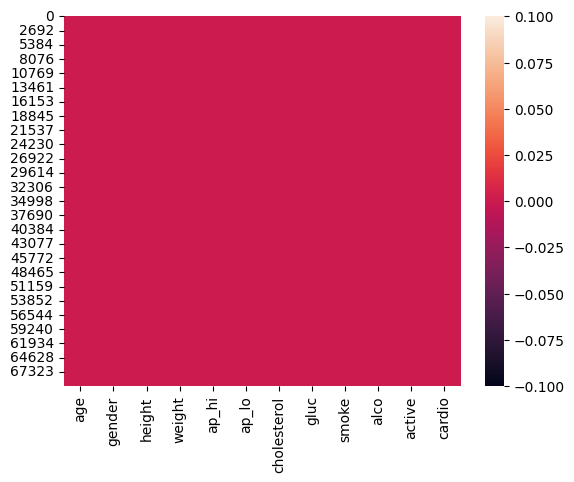

In [268]:
sns.heatmap(df.isnull())

**Donc on a pas de valeur manquante.**

## Columns transform

Je veux transformer certaines colonnes pour la comprehension et l'efficacité.

In [269]:
df['age']=df['age']//365.25
df['bmi']=df['weight']/(df['height']/100)**2
df.drop(['weight','height'],axis=1,inplace=True)
df = df.rename(columns={
    'ap_hi': 'systolic_pressure',
    'ap_lo': 'diastolic_pressure',
    'gluc': 'glucose',
    'smoke': 'smoking_status' ,
    'active':'physical_activity',
    'alco':'alcohol_status'
})
df.head()

,age,gender,systolic_pressure,diastolic_pressure,cholesterol,glucose,smoking_status,alcohol_status,physical_activity,cardio,bmi
0,50.0,2,110,80,1,1,0,0,1,0,21.967120
1,55.0,1,140,90,3,1,0,0,1,1,34.927679
2,51.0,1,130,70,3,1,0,0,0,1,23.507805
3,48.0,2,150,100,1,1,0,0,1,1,28.710479
4,47.0,1,100,60,1,1,0,0,0,0,23.011177


## Statistique(distribution des variables)

In [270]:
df.describe()

,age,gender,systolic_pressure,diastolic_pressure,cholesterol,glucose,smoking_status,alcohol_status,physical_activity,cardio,bmi
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,52.803475,1.349648,128.820453,96.636261,1.366997,1.226535,0.088159,0.053790,0.803718,0.499771,27.557610
std,6.762773,0.476862,154.037729,188.504581,0.680333,0.572353,0.283528,0.225604,0.397187,0.500004,6.092210
min,29.000000,1.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.471784
25%,48.000000,1.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,53.000000,1.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.391837
75%,58.000000,2.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.222222
max,64.000000,2.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,298.666667


In [271]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,69976.0,52.803475,6.762773,29.000000,48.000000,53.000000,58.000000,64.000000
gender,69976.0,1.349648,0.476862,1.000000,1.000000,1.000000,2.000000,2.000000
systolic_pressure,69976.0,128.820453,154.037729,-150.000000,120.000000,120.000000,140.000000,16020.000000
diastolic_pressure,69976.0,96.636261,188.504581,-70.000000,80.000000,80.000000,90.000000,11000.000000
cholesterol,69976.0,1.366997,0.680333,1.000000,1.000000,1.000000,2.000000,3.000000
glucose,69976.0,1.226535,0.572353,1.000000,1.000000,1.000000,1.000000,3.000000
smoking_status,69976.0,0.088159,0.283528,0.000000,0.000000,0.000000,0.000000,1.000000
alcohol_status,69976.0,0.053790,0.225604,0.000000,0.000000,0.000000,0.000000,1.000000
physical_activity,69976.0,0.803718,0.397187,0.000000,1.000000,1.000000,1.000000,1.000000
cardio,69976.0,0.499771,0.500004,0.000000,0.000000,0.000000,1.000000,1.000000


In [272]:
df.loc[df['systolic_pressure']<0,['systolic_pressure','diastolic_pressure']]

,systolic_pressure,diastolic_pressure
4607,-100,80
16021,-115,70
20536,-100,70
23988,-140,90
25240,-120,80
35040,-150,80
46627,-120,80


In [273]:
df[df['diastolic_pressure']>df['systolic_pressure']]

,age,gender,systolic_pressure,diastolic_pressure,cholesterol,glucose,smoking_status,alcohol_status,physical_activity,cardio,bmi
228,47.0,2,160,1100,1,2,1,0,1,1,29.263340
241,60.0,2,160,1000,2,1,0,0,0,1,24.341758
260,49.0,1,140,800,1,1,0,0,1,1,36.888889
329,64.0,1,160,1000,2,2,0,0,0,1,20.338326
345,51.0,1,140,1000,2,1,0,0,1,1,34.154158
...,...,...,...,...,...,...,...,...,...,...,...
69771,63.0,1,160,1000,1,1,0,0,1,1,29.043709
69872,59.0,1,160,1000,1,1,0,0,1,1,24.238227
69878,58.0,2,160,1000,1,1,0,0,1,1,33.659297
69885,61.0,2,170,1000,1,1,0,0,0,0,28.305995


In [274]:
df[df['diastolic_pressure']==1000]

,age,gender,systolic_pressure,diastolic_pressure,cholesterol,glucose,smoking_status,alcohol_status,physical_activity,cardio,bmi
241,60.0,2,160,1000,2,1,0,0,0,1,24.341758
329,64.0,1,160,1000,2,2,0,0,0,1,20.338326
345,51.0,1,140,1000,2,1,0,0,1,1,34.154158
559,55.0,2,200,1000,1,1,0,0,1,1,33.746533
613,51.0,1,140,1000,1,1,1,0,1,1,33.792470
...,...,...,...,...,...,...,...,...,...,...,...
69771,63.0,1,160,1000,1,1,0,0,1,1,29.043709
69872,59.0,1,160,1000,1,1,0,0,1,1,24.238227
69878,58.0,2,160,1000,1,1,0,0,1,1,33.659297
69885,61.0,2,170,1000,1,1,0,0,0,0,28.305995


In [275]:
df.loc[df['diastolic_pressure'] <=15,['systolic_pressure','diastolic_pressure']]

,systolic_pressure,diastolic_pressure
2014,906,0
6737,150,10
7598,120,8
9777,120,8
10106,150,10
13489,130,0
16459,138,0
17381,138,0
18898,110,7
19075,110,7


## Quelque valeur aberrante

**On constate qu'il y a eu une erreur de saisie sur les pressions artérielles et que on a toujours (systolic_pressure	>diastolic_pressure). Ce qui nous pousse à appliquer la valeur absolue sur systolic_pressure et supprimer le cas incoherent.**

In [276]:
df['systolic_pressure'] = df['systolic_pressure'].abs()

# On filtre la pression systolique (valeurs réalistes entre 80 et 220)
df = df.loc[(df['systolic_pressure'] >= 70) & (df['systolic_pressure'] <= 250)]

# On filtre la pression diastolique (valeurs réalistes entre 40 et 120)
df = df.loc[(df['diastolic_pressure'] >= 40) & (df['diastolic_pressure'] <= 140)]

# Sécurité finale : la systolique doit toujours être supérieure à la diastolique
df = df.loc[df['systolic_pressure'] > df['diastolic_pressure']]

In [277]:
print("la nouvelle taille du dataset :",df.shape)
print("on a ",round(df.shape[0]/70000,2),'% du dataset initiale')

la nouvelle taille du dataset : (68647, 11)
on a  0.98 % du dataset initiale


**Maintenant, je vais créer une variable d'écart des deux.**

In [278]:
df['diff_PS_PD']=df['systolic_pressure']-df['diastolic_pressure']

In [279]:
df.head()

,age,gender,systolic_pressure,diastolic_pressure,cholesterol,glucose,smoking_status,alcohol_status,physical_activity,cardio,bmi,diff_PS_PD
0,50.0,2,110,80,1,1,0,0,1,0,21.967120,30
1,55.0,1,140,90,3,1,0,0,1,1,34.927679,50
2,51.0,1,130,70,3,1,0,0,0,1,23.507805,60
3,48.0,2,150,100,1,1,0,0,1,1,28.710479,50
4,47.0,1,100,60,1,1,0,0,0,0,23.011177,40


## Séparation des variables

In [280]:
numerical_features=['age','systolic_pressure','diastolic_pressure','bmi','diff_PS_PD']
categorical_features=['gender','cholesterol','glucose','smoking_status','alcohol_status','physical_activity']

## Analyse univariée

### **Target**

<Axes: >

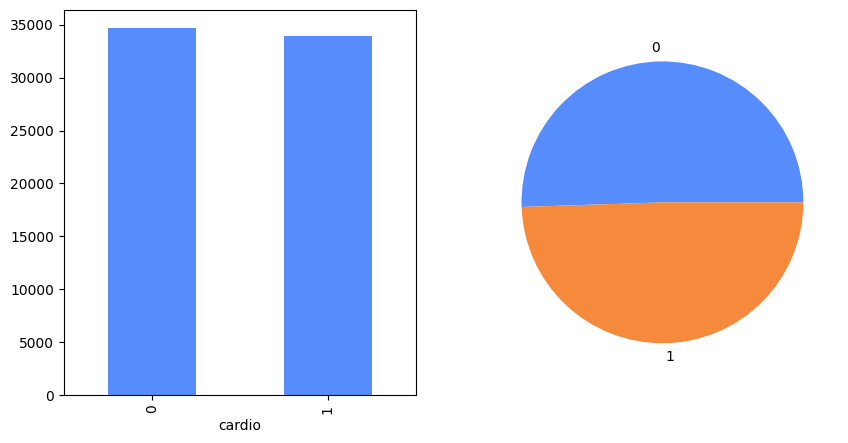

In [281]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
df["cardio"].value_counts().plot(kind="bar",ax=ax1)
df["cardio"].value_counts().plot(kind="pie",ax=ax2)

In [282]:
df["cardio"].value_counts(normalize=True)

cardio
0    0.505252
1    0.494748
Name: proportion, dtype: float64

**Le dataset est très bien équilibré.**

### **Histogramme des variables quantitatives**

C:\Users\tigan\AppData\Local\Temp\ipykernel_19172\3068668621.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\tigan\AppData\Local\Temp\ipykernel_19172\3068668621.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\tigan\AppData\Local\Temp\ipykernel_19172\30

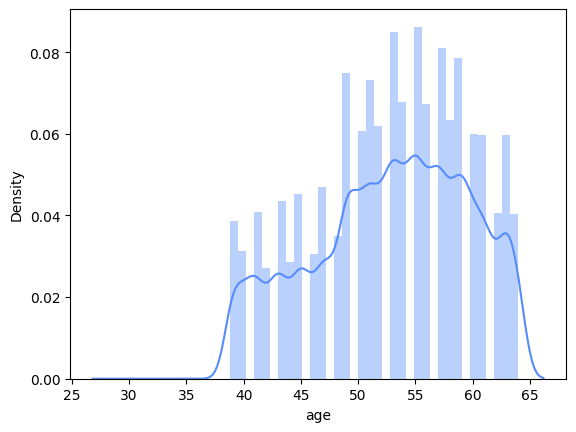

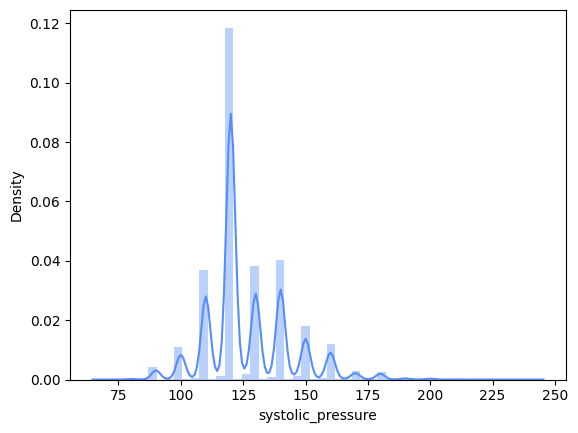

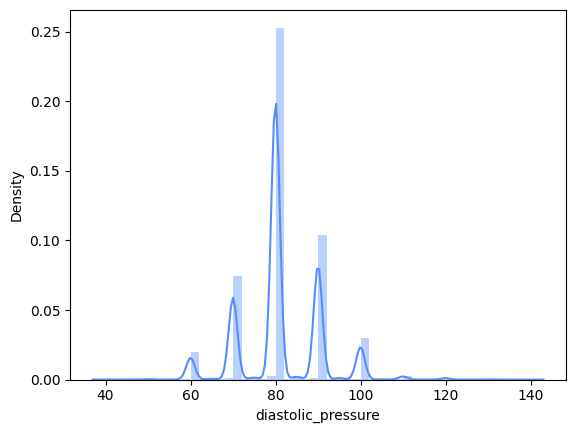

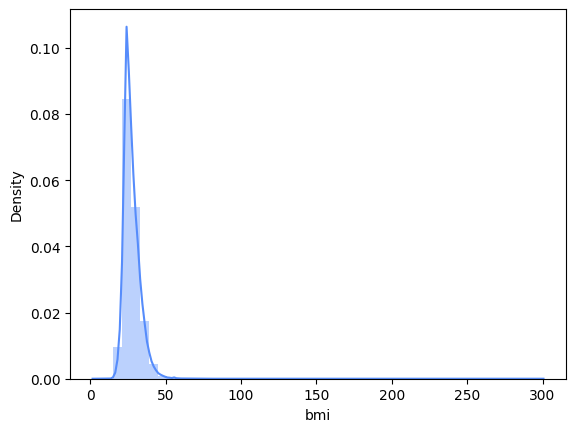

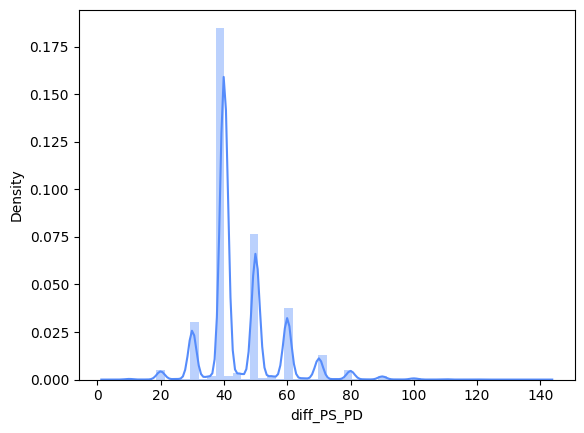

In [283]:
for col in numerical_features :
    plt.figure()
    sns.distplot(df[col])

### **Diagramme en bar et pie des variables categorielles**

**Gender : 1 : F et 2 : H**

**1 : normal, 2 : modérée, 3 : élevée**

**1 : positive et 0 : négative**

<Figure size 640x480 with 0 Axes>

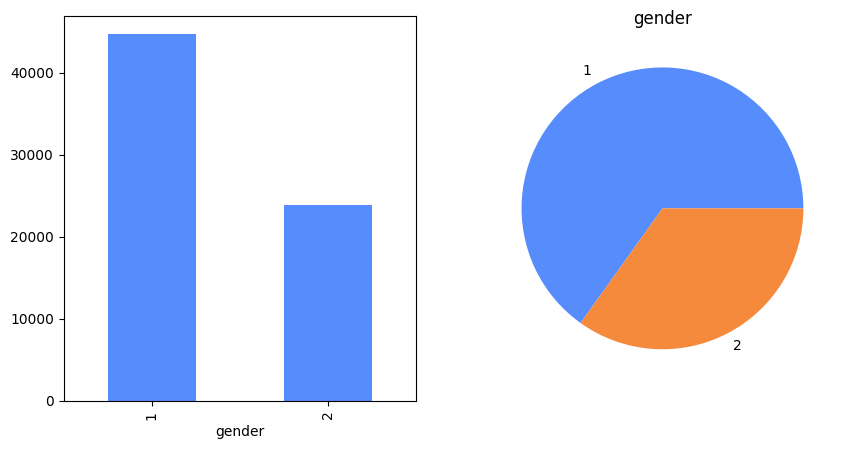

<Figure size 640x480 with 0 Axes>

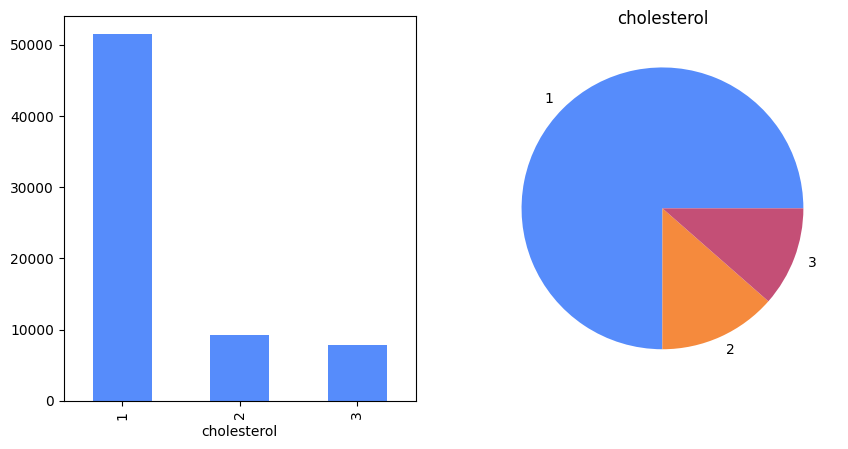

<Figure size 640x480 with 0 Axes>

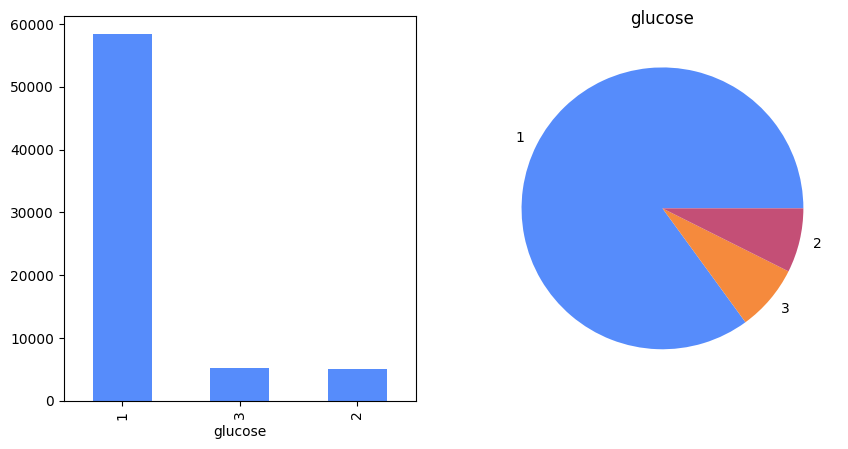

<Figure size 640x480 with 0 Axes>

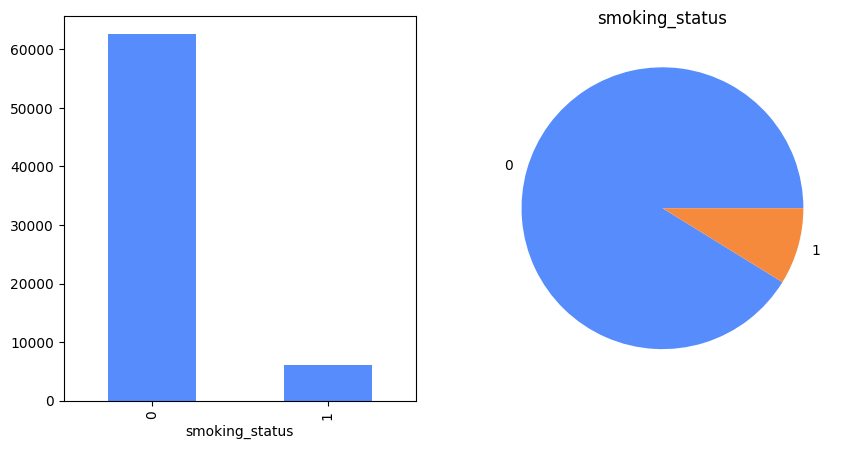

<Figure size 640x480 with 0 Axes>

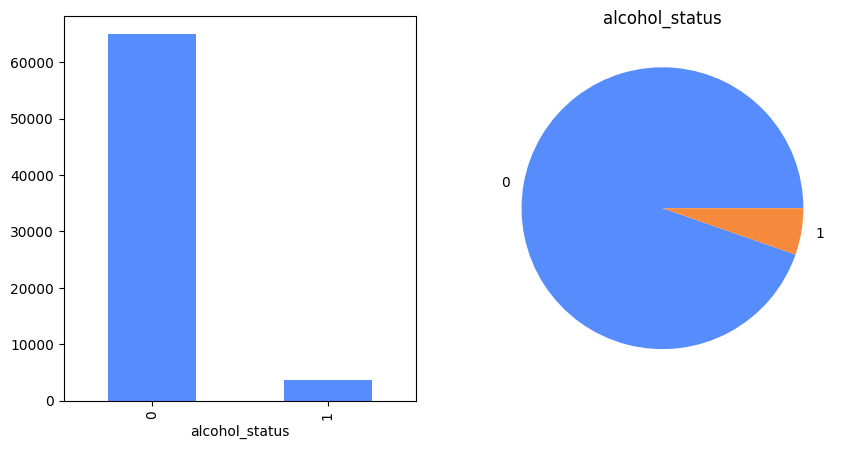

<Figure size 640x480 with 0 Axes>

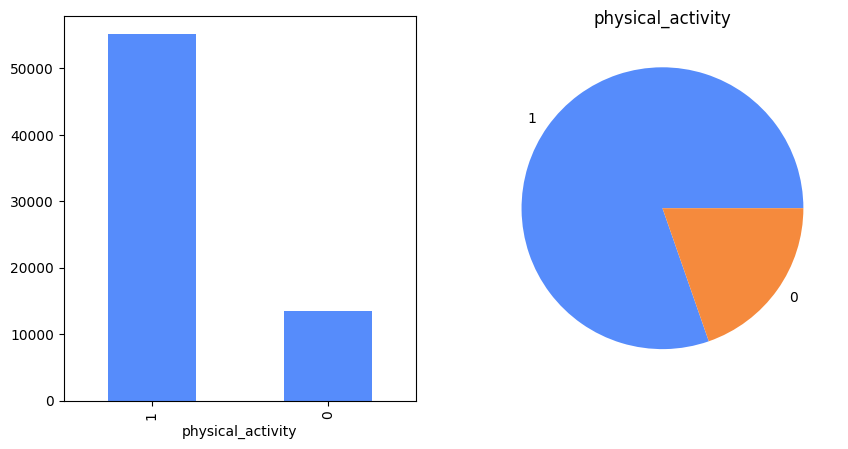

In [284]:
for col in categorical_features:
    plt.figure()
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
    df[col].value_counts().plot(kind="bar",ax=ax1)
    df[col].value_counts().plot(kind="pie",ax=ax2)
    plt.title(col)
    plt.legend

In [285]:
for col in categorical_features:
    print(df[col].value_counts(normalize=True))

gender
1    0.651274
2    0.348726
Name: proportion, dtype: float64
cholesterol
1    0.749880
2    0.135505
3    0.114615
Name: proportion, dtype: float64
glucose
1    0.850248
3    0.075968
2    0.073783
Name: proportion, dtype: float64
smoking_status
0    0.911999
1    0.088001
Name: proportion, dtype: float64
alcohol_status
0    0.946625
1    0.053375
Name: proportion, dtype: float64
physical_activity
1    0.803342
0    0.196658
Name: proportion, dtype: float64


### **Boxplot**

<Axes: >

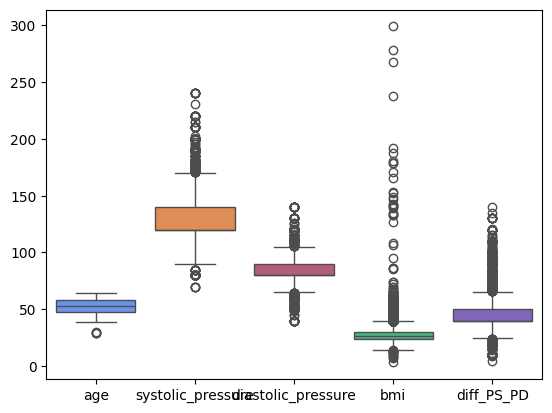

In [286]:
sns.boxplot(df[numerical_features])

**Age est parfait comme ça.**

**Pour les pession c'est aussi réaliste, ils représentent hypotension et hypertension sévère.**

**On a un problème au niveau de bmi, des outliers.**

**La difference des pression est bien, mais les cas qui raprochent de 0 doivent être supprimé.**

In [287]:
print((df['bmi']>70).sum(),'soit ',round((df['bmi']>70).sum()/df.shape[0]*100,3),'du dataset')

34 soit  0.05 du dataset


In [288]:
df=df[df['bmi']<70]
df.shape

(68612, 12)

**Pression differencielle le plus bas est environ 15 à 20.**

In [289]:
(df['diff_PS_PD']<15).sum()

np.int64(76)

In [290]:
df=df[df['diff_PS_PD']>=15]

<Axes: >

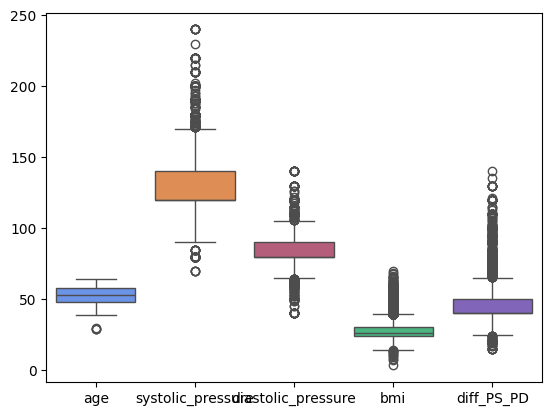

In [291]:
sns.boxplot(df[numerical_features])

**Parfait**

### Analyse bivariée

#### Quelque groupément

In [292]:
df.groupby("gender").mean().T

gender,1,2
age,52.907793,52.579848
systolic_pressure,125.941517,128.113560
diastolic_pressure,80.823474,82.162874
cholesterol,1.383078,1.330642
glucose,1.234606,1.209260
smoking_status,0.017769,0.219132
alcohol_status,0.025208,0.105906
physical_activity,0.801604,0.806592
cardio,0.492337,0.499707
bmi,27.882826,26.675663


In [293]:
df.groupby("cholesterol").mean().T

cholesterol,1,2,3
age,52.284936,53.168588,55.675277
gender,1.358680,1.327804,1.309327
systolic_pressure,124.843192,130.915868,133.855961
diastolic_pressure,80.441783,83.059571,84.752895
glucose,1.099311,1.334590,1.924163
smoking_status,0.085127,0.105892,0.085762
alcohol_status,0.047807,0.075407,0.063621
physical_activity,0.802312,0.797695,0.816771
cardio,0.435537,0.596682,0.762947
bmi,26.959670,28.528671,29.484611


In [294]:
df.groupby("glucose").mean().T

glucose,1,2,3
age,52.542921,53.390196,55.016516
gender,1.352617,1.339790,1.315345
systolic_pressure,125.974893,131.181063,130.450355
diastolic_pressure,80.962948,83.378138,82.930478
cholesterol,1.248876,1.665349,2.369887
smoking_status,0.087884,0.103973,0.073939
alcohol_status,0.051519,0.077881,0.050125
physical_activity,0.805097,0.787705,0.798925
cardio,0.475768,0.588654,0.618014
bmi,27.167743,29.383511,28.884377


In [295]:
df.groupby("smoking_status").mean().T

smoking_status,0,1
age,52.893159,51.759615
gender,1.298685,1.868534
systolic_pressure,126.554605,128.197613
diastolic_pressure,81.215666,82.068302
cholesterol,1.362697,1.386439
glucose,1.226817,1.214854
alcohol_status,0.029598,0.299569
physical_activity,0.800237,0.835544
cardio,0.497456,0.468501
bmi,27.516857,26.890401


In [296]:
df.groupby("alcohol_status").mean().T

alcohol_status,0,1
age,52.839547,51.974569
gender,1.329475,1.692371
systolic_pressure,126.557576,129.211922
diastolic_pressure,81.206692,82.781241
cholesterol,1.359145,1.464862
glucose,1.224372,1.250479
smoking_status,0.065121,0.494121
physical_activity,0.801045,0.844135
cardio,0.495923,0.476894
bmi,27.440518,27.837873


<Axes: >

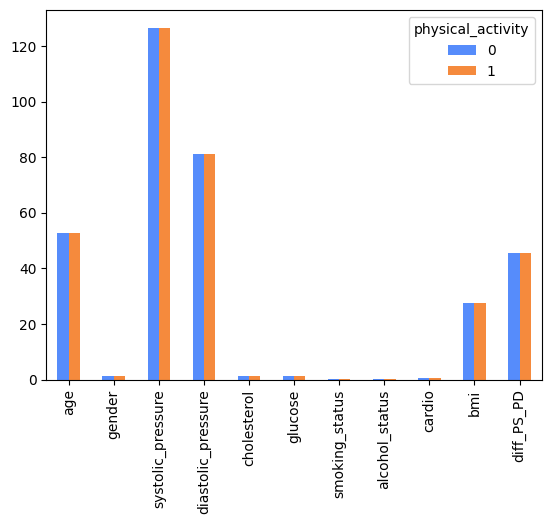

In [297]:
x=df.groupby("physical_activity").mean().T
x.plot(kind="bar")

In [298]:
x

physical_activity,0,1
age,52.933892,52.759000
gender,1.343078,1.350249
systolic_pressure,126.731563,126.691289
diastolic_pressure,81.302270,81.287878
cholesterol,1.353020,1.367667
glucose,1.235050,1.223492
smoking_status,0.073601,0.091540
alcohol_status,0.042291,0.056068
cardio,0.532943,0.485597
bmi,27.616185,27.423908


#### **Relation target / variables**

In [299]:
df_pos=df[df["cardio"]==0]
df_neg=df[df["cardio"]==1]

C:\Users\tigan\AppData\Local\Temp\ipykernel_19172\1609468434.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_pos[col],label="positive")
C:\Users\tigan\AppData\Local\Temp\ipykernel_19172\1609468434.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_neg[col],label="négative")
C:\Users\t

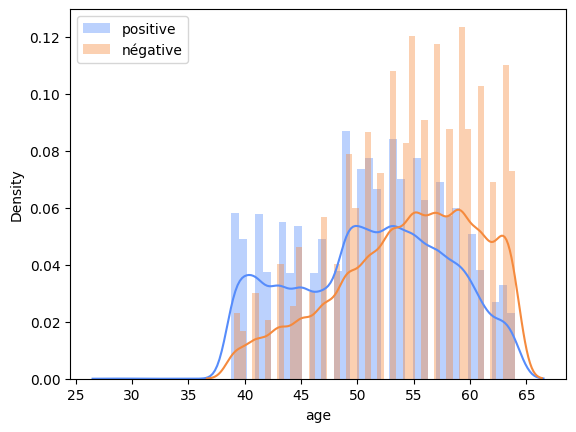

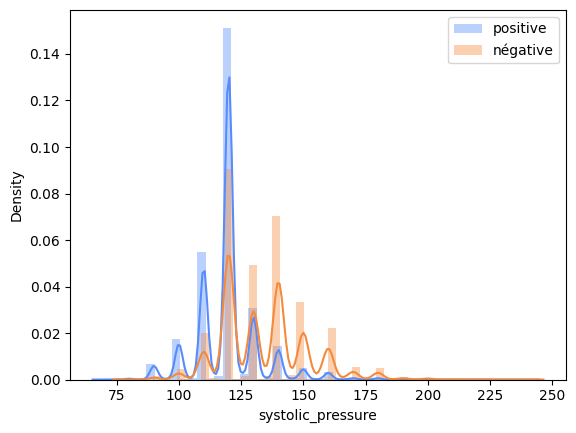

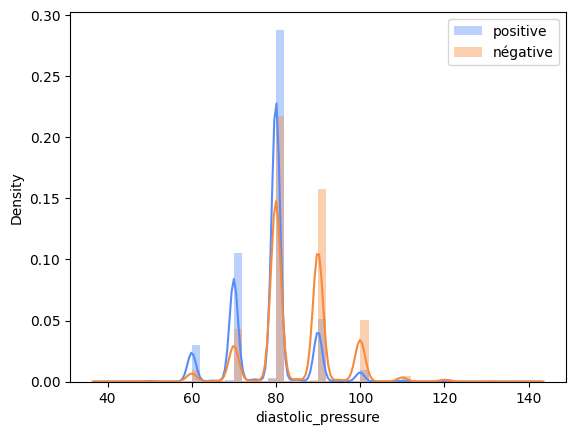

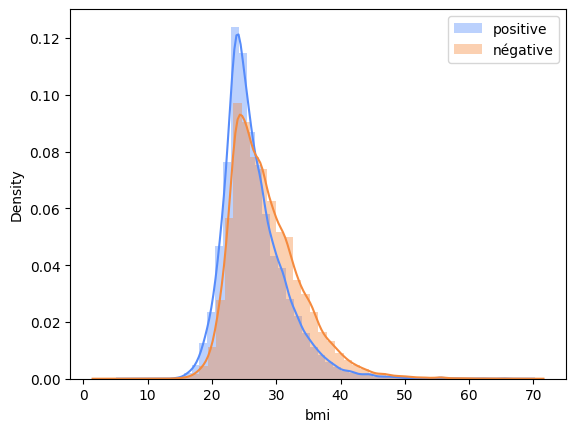

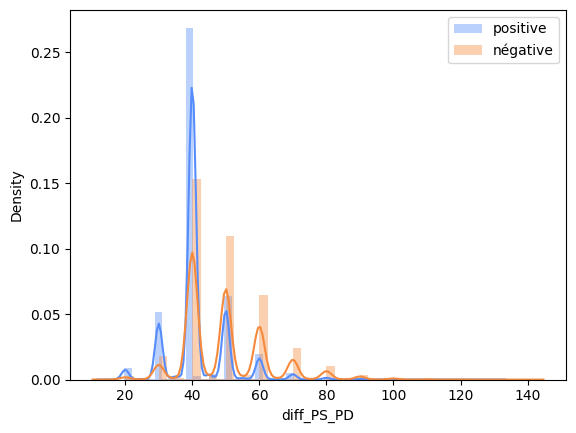

In [300]:
for col in numerical_features :
    plt.figure()
    sns.distplot(df_pos[col],label="positive")
    sns.distplot(df_neg[col],label="négative")
    plt.legend()

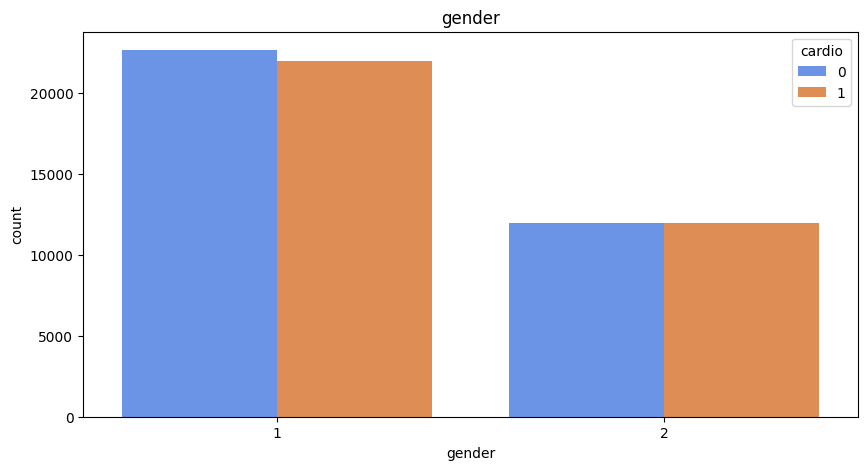

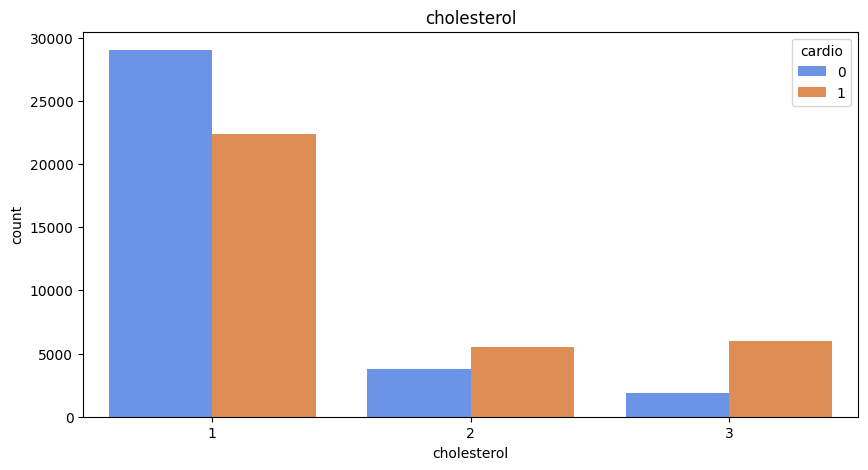

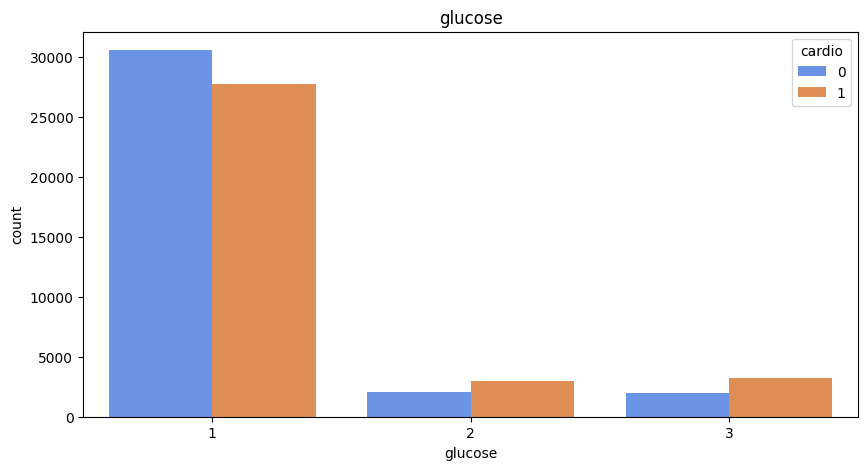

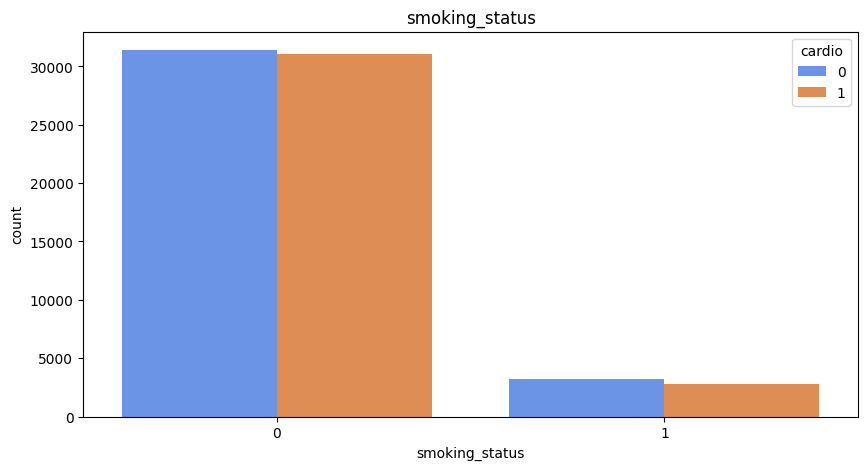

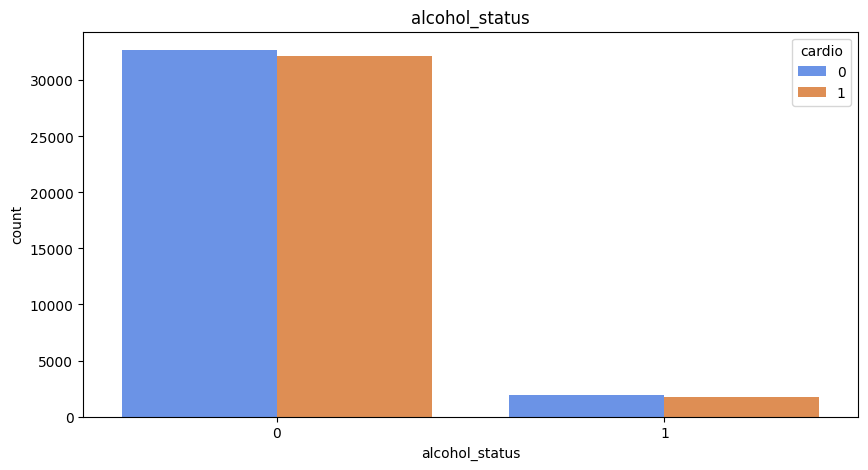

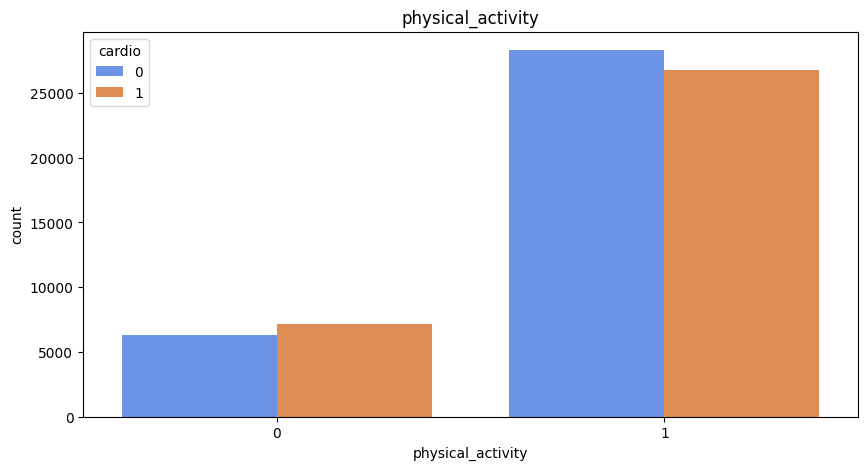

In [301]:
for col in categorical_features :
    plt.figure(figsize=(10,5))
    sns.countplot(x=col,hue="cardio",data=df)
    plt.title(col)

**Boxplot**

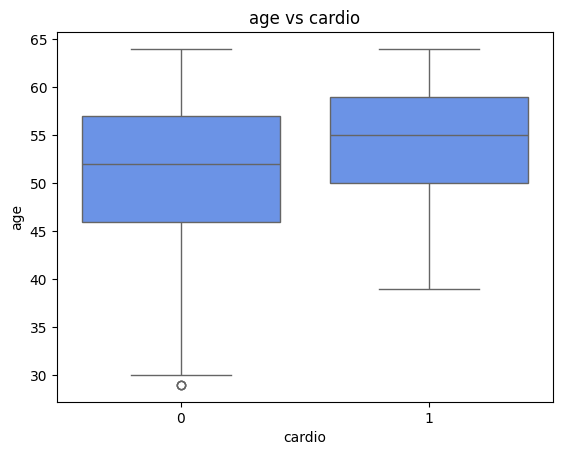

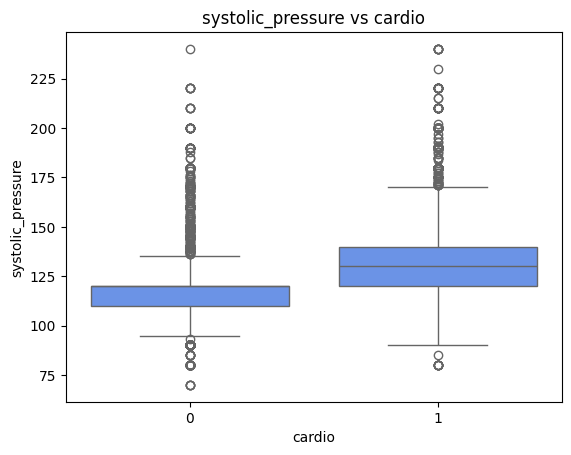

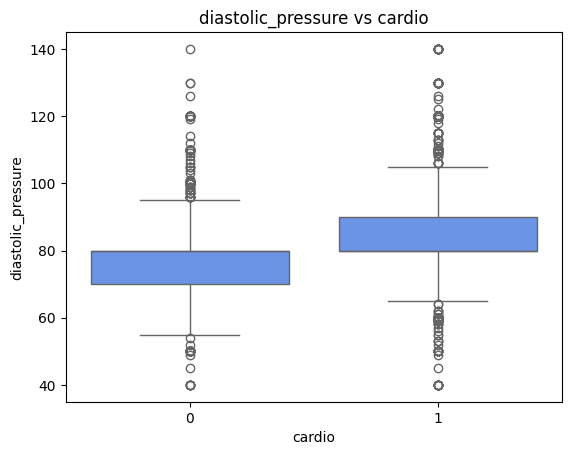

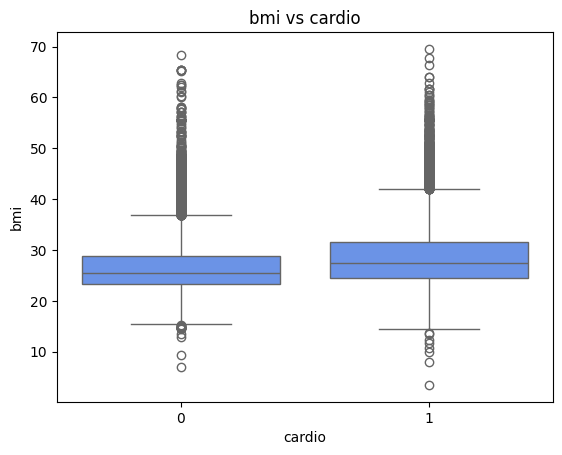

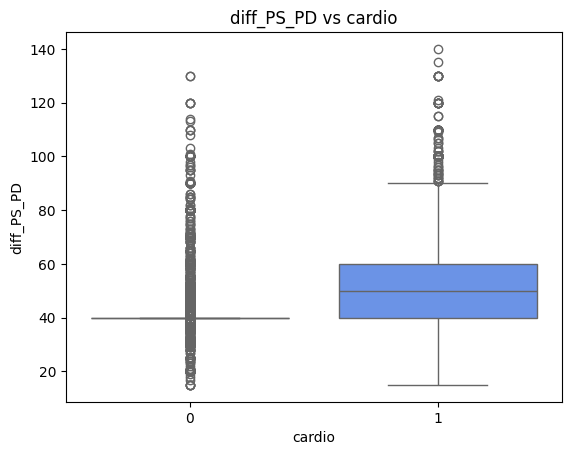

In [303]:
for col in numerical_features :
    sns.boxplot(x='cardio', y=col, data=df)
    plt.title(f'{col} vs cardio')
    plt.show()

## Analyse Multivariée

#### pairplot

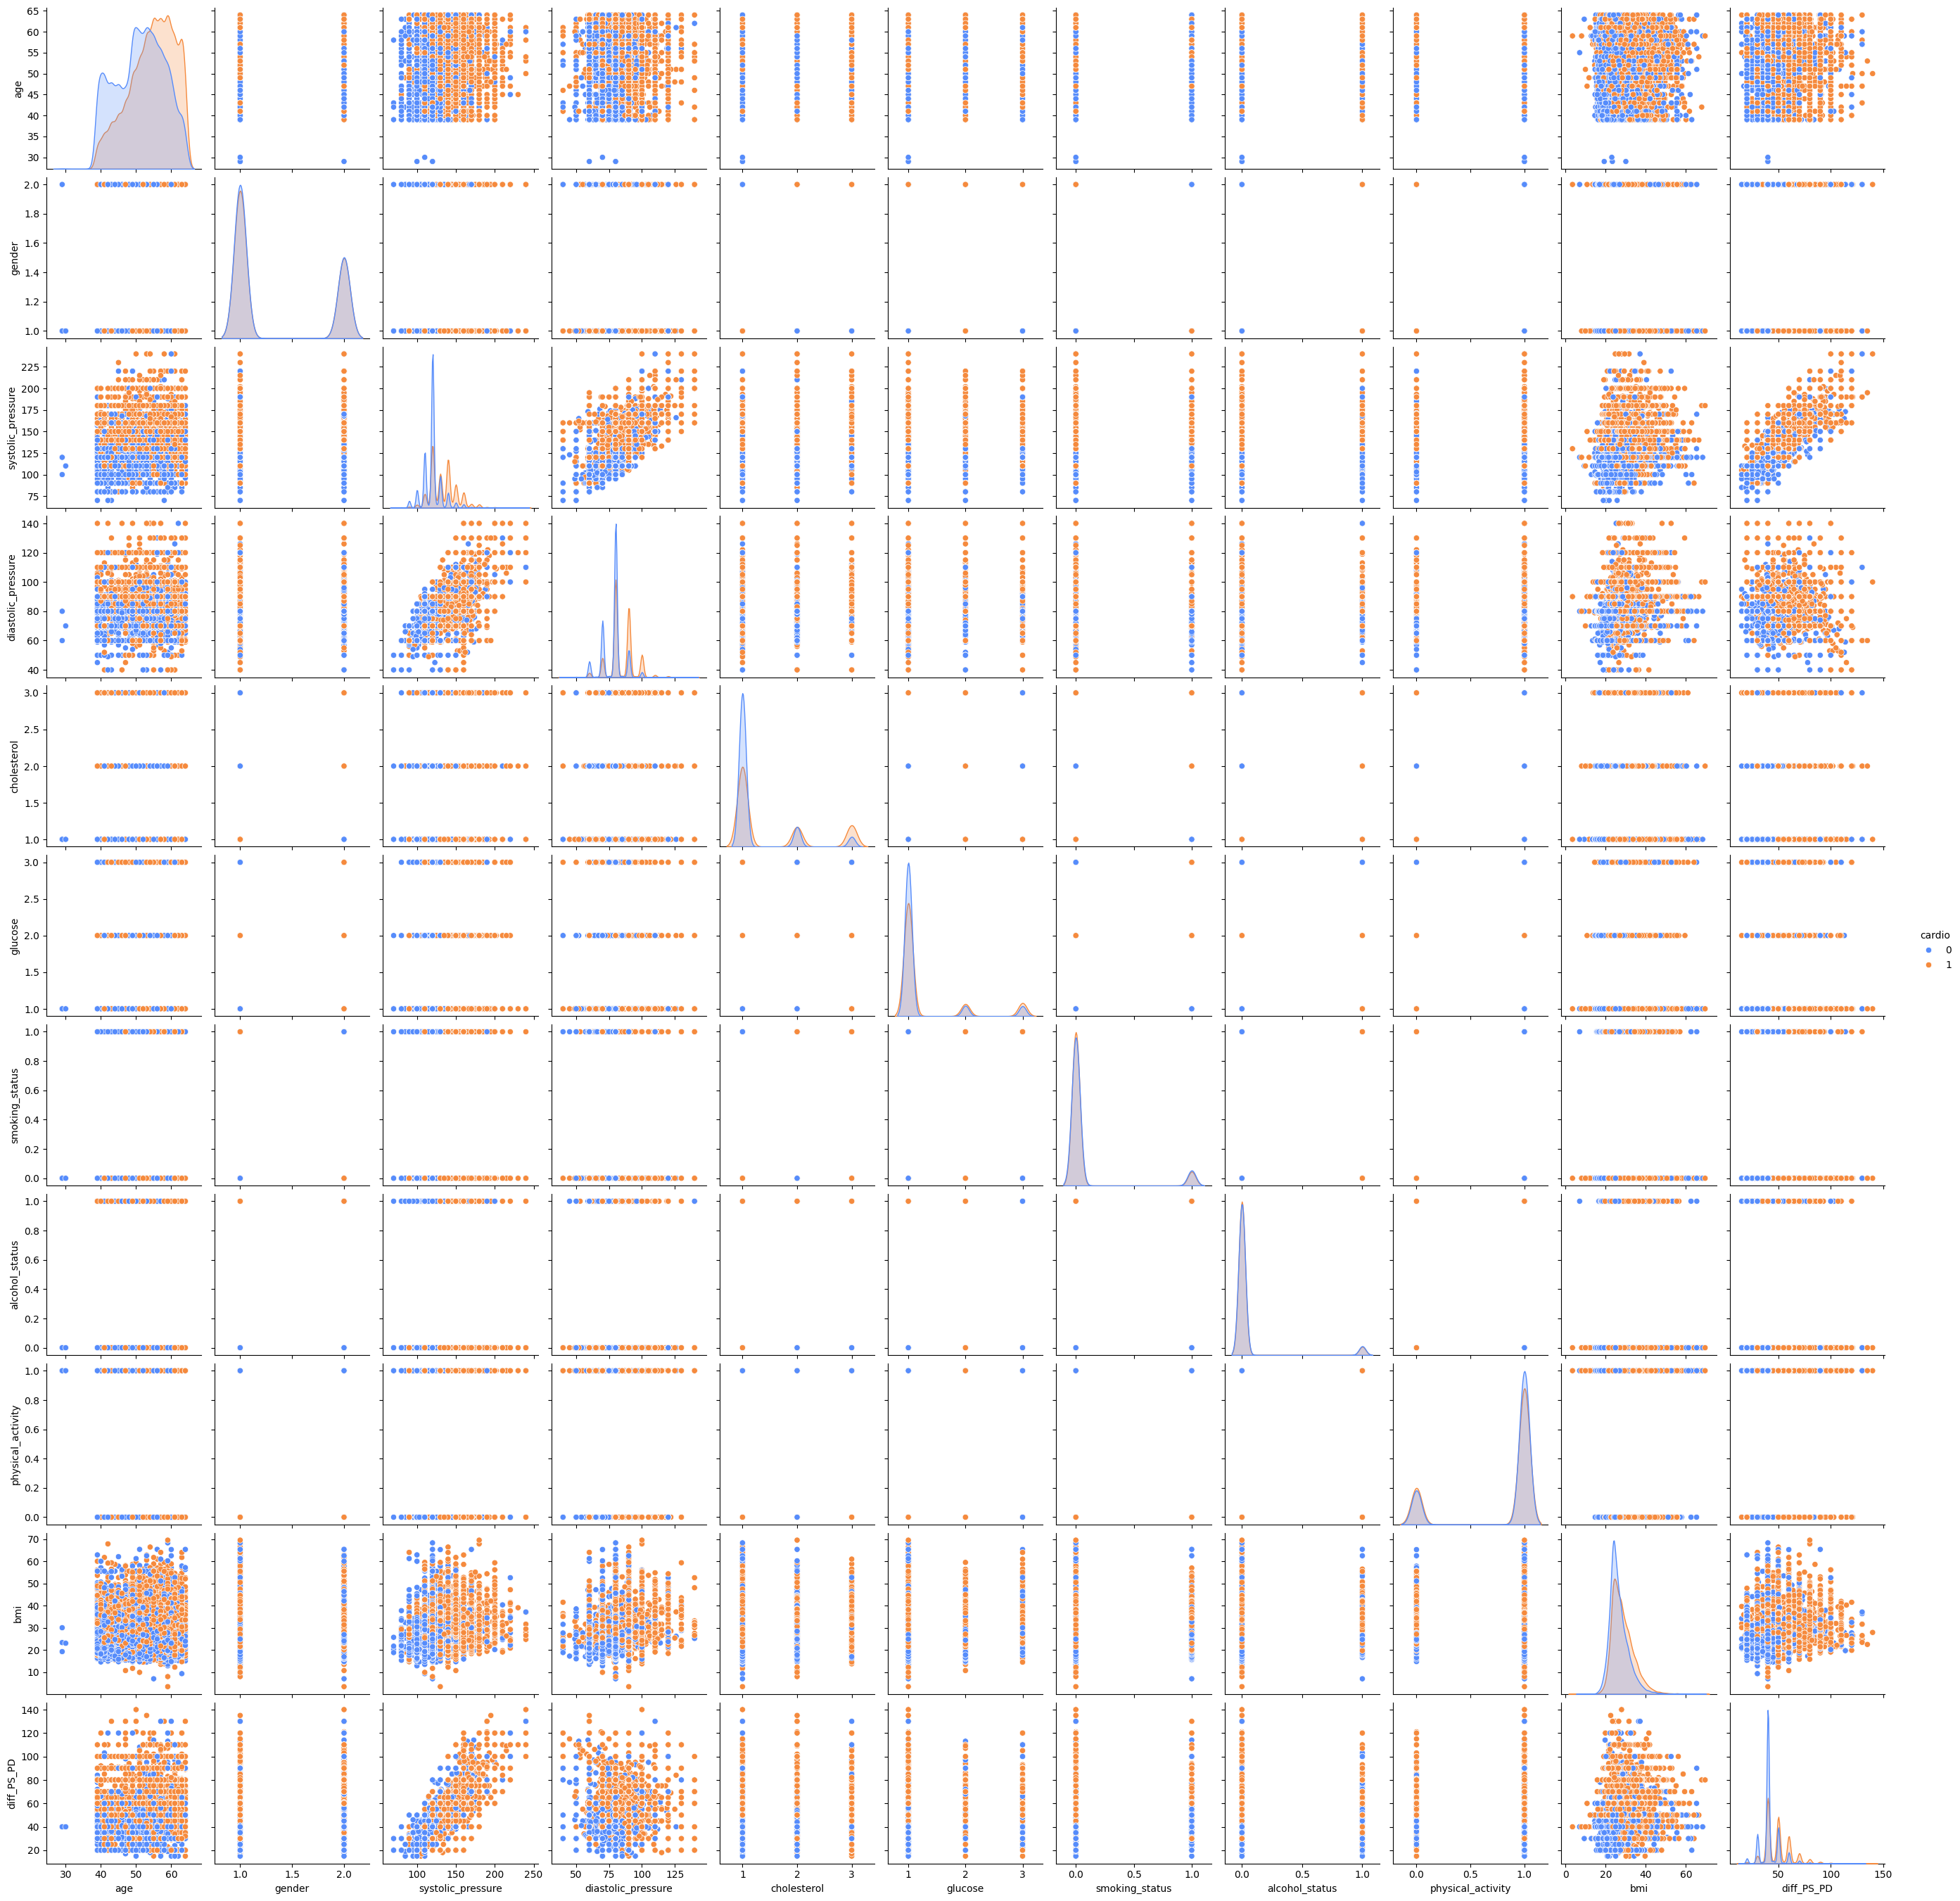

In [304]:
sns.pairplot(df,hue="cardio")

**bmi en fonction d'age et cardio**

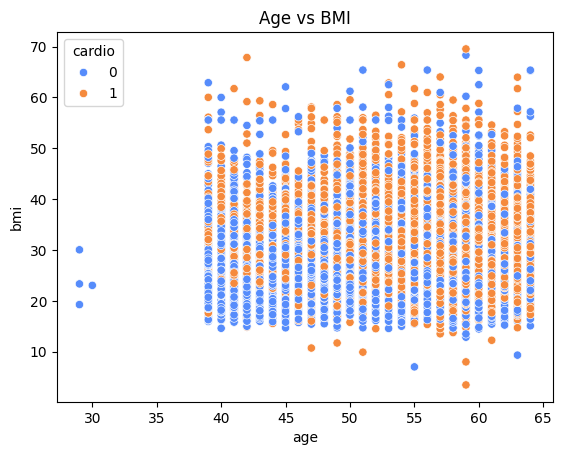

In [306]:
sns.scatterplot(x='age', y='bmi', hue='cardio', data=df)
plt.title('Age vs BMI')
plt.show()

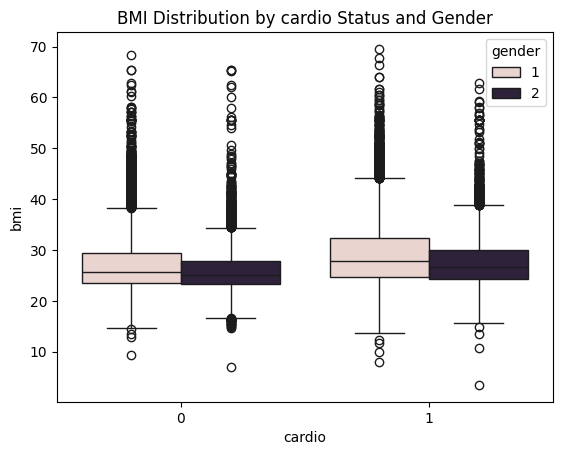

In [307]:
sns.boxplot(x='cardio', y='bmi', hue='gender', data=df)
plt.title('BMI Distribution by cardio Status and Gender')
plt.show()

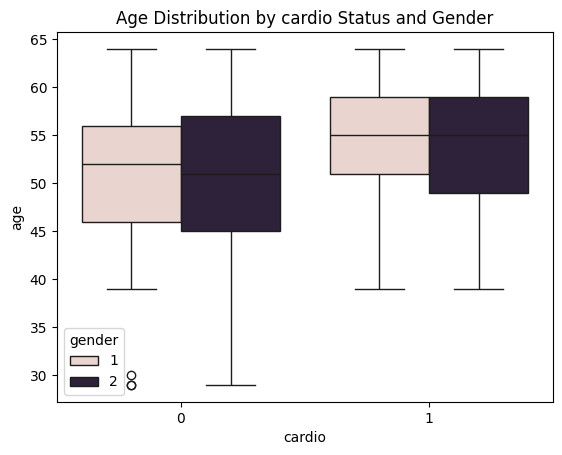

In [308]:
sns.boxplot(x='cardio', y='age', hue='gender', data=df)
plt.title('Age Distribution by cardio Status and Gender')
plt.show()

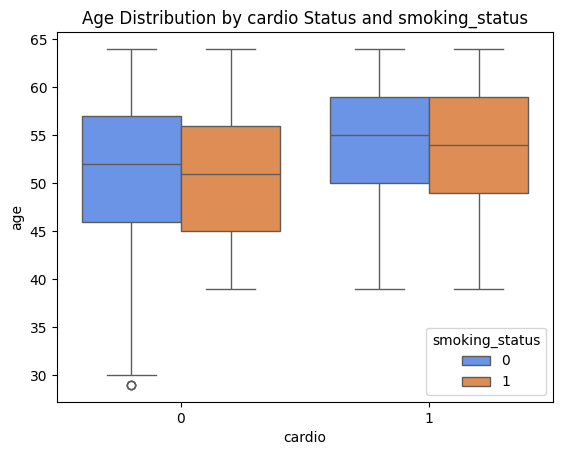

In [309]:
sns.boxplot(x='cardio', y='age', hue='smoking_status', data=df)
plt.title('Age Distribution by cardio Status and smoking_status')
plt.show()

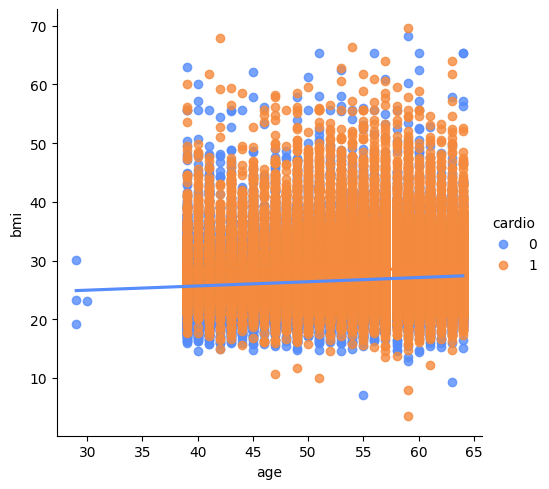

In [311]:
sns.lmplot(x='age', y='bmi', data=df,hue='cardio')

<Axes: xlabel='cardio', ylabel='bmi'>

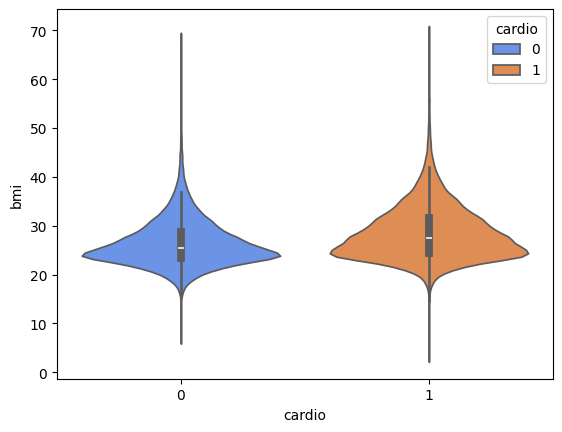

In [313]:
sns.violinplot(x='cardio', y='bmi', data=df,hue='cardio')

<Axes: xlabel='cardio', ylabel='age'>

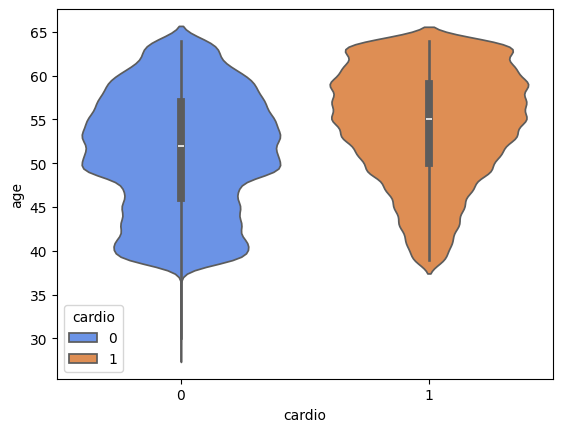

In [314]:
sns.violinplot(x='cardio', y='age', data=df,hue='cardio')

<Axes: xlabel='cardio', ylabel='diff_PS_PD'>

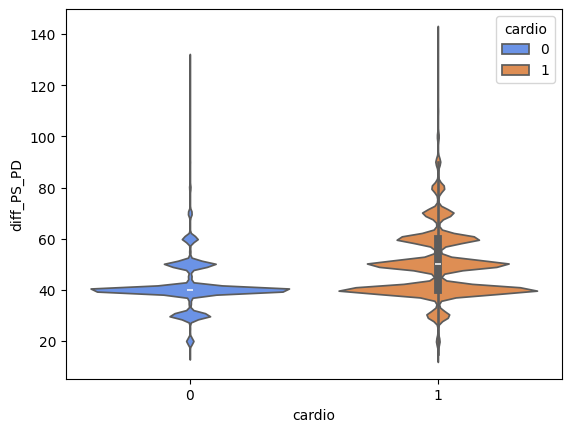

In [315]:
sns.violinplot(x='cardio', y='diff_PS_PD', data=df,hue='cardio')

## Corrélation

<Figure size 2000x1000 with 0 Axes>

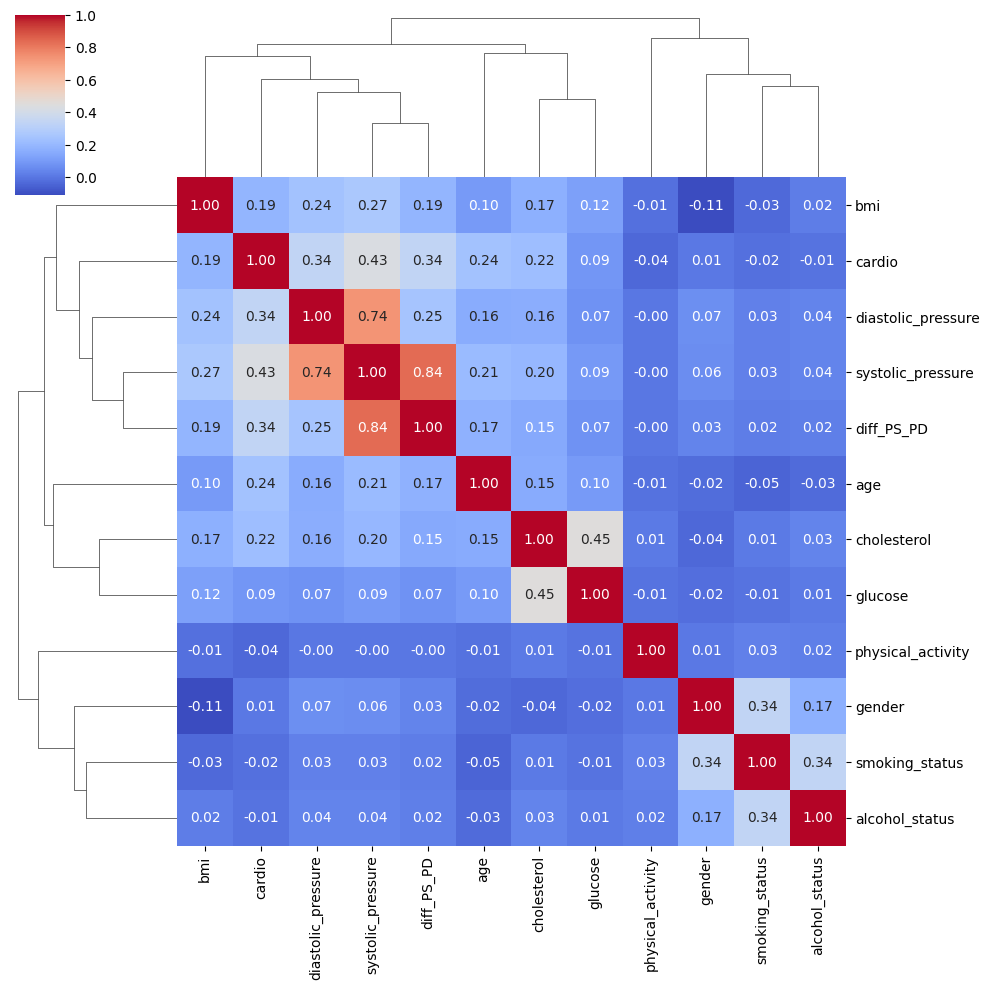

In [316]:
plt.figure(figsize=(20,10))
sns.clustermap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm")

<Axes: >

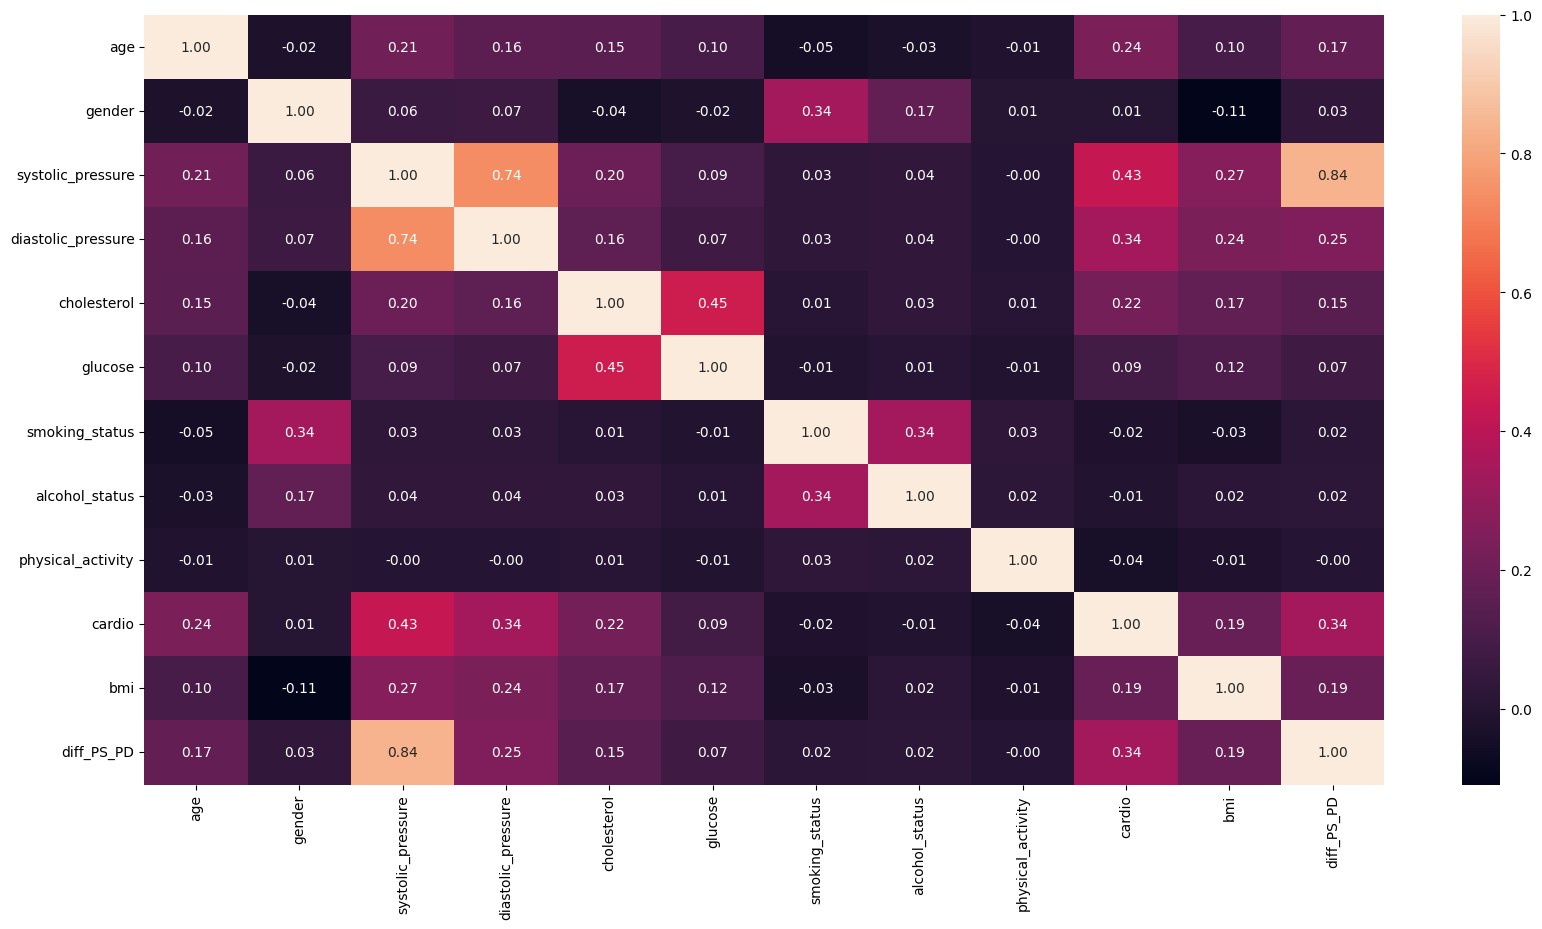

In [318]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True,fmt=".2f")

**La forte corrélation (0.84) montre que la différence apporte presque la même information que la pression systolique. Pour éviter cette redondance inutile (colinéarité) qui perturbe le modèle, il vaut mieux supprimer la colonne de différence et ne garder que les deux tensions de base (systolic_pressure et diastolic_pressure).**